In [ ]:
!pip install -q xgboost lightgbm catboost pytorch-tabnet imbalanced-learn

In [ ]:
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')

# UPDATED: Pointing directly to the CSV in your Google Drive!
DATA_PATH = Path('/content/drive/MyDrive/Combined.csv')
OUTPUT_DIR = Path('/content/drive/MyDrive/5gnidd_outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Input dataset path: {DATA_PATH}')
print(f'Artifacts output path: {OUTPUT_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Input dataset path: /content/drive/MyDrive/Combined.csv
Artifacts output path: /content/drive/MyDrive/5gnidd_outputs


In [ ]:
import os
import gc
import time
import random
import warnings
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)
from sklearn.ensemble import RandomForestClassifier

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from pytorch_tabnet.tab_model import TabNetClassifier

import torch

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
TEST_START_ROW = 800_000
VAL_SIZE = 0.15
LCCDE_CONFIDENCE_THRESHOLD = 0.80
N_CLASSES = 9

ATTACK_TYPE_NAMES = [
    'Benign',
    'UDPFlood',
    'HTTPFlood',
    'SlowrateDoS',
    'TCPConnectScan',
    'SYNScan',
    'UDPScan',
    'SYNFlood',
    'ICMPFlood',
]

BINARY_FEATURES_NORMALIZED = [
    'seq', 'offset', 'sttl', 'ackdat', 'tcprtt', 'smeanpktsz',
    'shops', 'dttl', 'srcbytes', 'totbytes', 'dmeanpktsz',
    'srcwin', 'stos',
]

MULTICLASS_FEATURES_NORMALIZED = [
    'ackdat', 'shops', 'seq', 'tcprtt', 'dmeanpktsz', 'offset', 'sttl',
    'srctcpbase', 'smeanpktsz', 'dstloss', 'loss', 'dttl', 'srcbytes',
    'totbytes',
]

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU device:', torch.cuda.get_device_name(0))

CUDA available: True
GPU device: Tesla T4


In [ ]:
def load_and_preprocess_raw_data(csv_path: str) -> pd.DataFrame:
    """
    Load raw Combined.csv and transform it into the target 48-column schema.
    """
    df = pd.read_csv(csv_path)
    print(f'Raw shape: {df.shape}')

    cols_to_drop = [
        'Unnamed: 0', 'RunTime', 'Sum', 'Min', 'Max',
        'SrcGap', 'DstGap', 'sDSb', 'dDSb', 'Attack Tool',
    ]
    df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True, errors='ignore')

    df.fillna(0, inplace=True)

    attack_type_map = {
        'Benign': 0,
        'UDPFlood': 1,
        'UDP Flood': 1,
        'HTTPFlood': 2,
        'HTTP Flood': 2,
        'SlowrateDoS': 3,
        'Slowrate DoS': 3,
        'TCPConnectScan': 4,
        'TCP Connect Scan': 4,
        'SYNScan': 5,
        'SYN Scan': 5,
        'UDPScan': 6,
        'UDP Scan': 6,
        'SYNFlood': 7,
        'SYN Flood': 7,
        'ICMPFlood': 8,
        'ICMP Flood': 8,
    }

    if 'Attack Type' in df.columns:
        df['Attack Type_'] = df['Attack Type'].map(attack_type_map).fillna(0).astype(int)
        df.drop(columns=['Attack Type'], inplace=True)
    elif 'Attack Type_' not in df.columns:
        raise ValueError("No 'Attack Type' column found in raw data.")

    if 'Label' in df.columns:
        df['Label__Malicious'] = (df['Label'].astype(str).str.strip().str.lower() != 'benign').astype(int)
        df.drop(columns=['Label'], inplace=True)
    elif 'Label__Malicious' not in df.columns:
        df['Label__Malicious'] = (df['Attack Type_'] != 0).astype(int)

    if 'Proto' in df.columns:
        df['Proto'] = df['Proto'].astype(str).str.strip().str.lower()
        df['Proto_icmp'] = (df['Proto'] == 'icmp').astype(int)
        df['Proto_tcp'] = (df['Proto'] == 'tcp').astype(int)
        df['Proto_udp'] = (df['Proto'] == 'udp').astype(int)
        df.drop(columns=['Proto'], inplace=True)

    if 'Cause' in df.columns:
        df['Cause'] = df['Cause'].astype(str).str.strip().str.lower()
        df['Cause_Status'] = (df['Cause'] == 'status').astype(int)
        df.drop(columns=['Cause'], inplace=True)

    if 'State' in df.columns:
        df['State'] = df['State'].astype(str).str.strip().str.upper()
        for state_val in ['CON', 'ECO', 'FIN', 'INT', 'REQ', 'RST']:
            df[f'State_{state_val}'] = (df['State'] == state_val).astype(int)
        df.drop(columns=['State'], inplace=True)

    if 'Mean' in df.columns:
        df.drop(columns=['Mean'], inplace=True)

    rename_map = {
        'sTos': 'sTos_',
        'dTos': 'dTos_',
        'sTtl': 'sTtl_',
        'dTtl': 'dTtl_',
        'SrcWin': 'SrcWin_',
        'DstWin': 'DstWin_',
        'sVid': 'sVid_',
        'dVid': 'dVid_',
        'SrcTCPBase': 'SrcTCPBase_',
        'DstTCPBase': 'DstTCPBase_',
    }
    df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns}, inplace=True)

    target_columns = [
        'Seq', 'Dur', 'sHops', 'dHops', 'TotPkts', 'SrcPkts', 'DstPkts',
        'TotBytes', 'SrcBytes', 'DstBytes', 'Offset', 'sMeanPktSz', 'dMeanPktSz',
        'Load', 'SrcLoad', 'DstLoad', 'Loss', 'SrcLoss', 'DstLoss', 'pLoss',
        'Rate', 'SrcRate', 'DstRate', 'TcpRtt', 'SynAck', 'AckDat',
        'sTos_', 'dTos_', 'sTtl_', 'dTtl_', 'SrcWin_', 'DstWin_',
        'sVid_', 'dVid_', 'SrcTCPBase_', 'DstTCPBase_',
        'Attack Type_',
        'Proto_icmp', 'Proto_tcp', 'Proto_udp',
        'Cause_Status',
        'State_CON', 'State_ECO', 'State_FIN', 'State_INT', 'State_REQ', 'State_RST',
        'Label__Malicious',
    ]

    available_target_cols = [c for c in target_columns if c in df.columns]
    df = df[available_target_cols].copy()

    print(f'Preprocessed shape: {df.shape}')
    print(f'Columns count: {len(df.columns)}')
    if len(df.columns) != 48:
        print('Warning: expected 48 columns, found', len(df.columns))

    return df


def normalize_column_names(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [col.lower().replace('_', '') for col in df.columns]
    return df

In [ ]:
df_raw = load_and_preprocess_raw_data(str(DATA_PATH))
df = normalize_column_names(df_raw)

missing_feats = [c for c in MULTICLASS_FEATURES_NORMALIZED if c not in df.columns]
if missing_feats:
    raise ValueError(f'Missing required multiclass features: {missing_feats}')

if 'attack type' not in df.columns:
    raise ValueError("Expected multiclass target column 'attack type' after normalization.")

df_train_all = df.iloc[:TEST_START_ROW].copy()
df_test = df.iloc[TEST_START_ROW:].copy()

X_all = df_train_all[MULTICLASS_FEATURES_NORMALIZED].copy()
y_all = df_train_all['attack type'].astype(int).copy()

X_test = df_test[MULTICLASS_FEATURES_NORMALIZED].copy()
y_test = df_test['attack type'].astype(int).copy()

print('Train rows used for modeling:', len(X_all))
print('Unseen test rows:', len(X_test))
print('Class distribution (train-all):')
print(y_all.value_counts().sort_index())

Raw shape: (1215890, 52)
Preprocessed shape: (1215890, 48)
Columns count: 48
Train rows used for modeling: 800000
Unseen test rows: 415890
Class distribution (train-all):
attack type
0    428634
1    197205
2     76121
3     36092
4     20052
5     20043
6     15906
7      4792
8      1155
Name: count, dtype: int64


In [ ]:
def resample_to_exact_50k_per_class(X_train: pd.DataFrame, y_train: pd.Series, random_state: int = 42):
    """
    Hybrid strategy: RandomUnderSampler followed by SMOTE so each class has exactly 50,000 samples.
    """
    current_counts = y_train.value_counts().to_dict()

    under_target = {cls: min(count, 50_000) for cls, count in current_counts.items()}
    rus = RandomUnderSampler(sampling_strategy=under_target, random_state=random_state)
    X_under, y_under = rus.fit_resample(X_train, y_train)

    smote_target = {cls: 50_000 for cls in range(N_CLASSES)}
    smote = SMOTE(sampling_strategy=smote_target, random_state=random_state, k_neighbors=5)
    X_bal, y_bal = smote.fit_resample(X_under, y_under)

    return X_bal, y_bal


X_train_base, X_val, y_train_base, y_val = train_test_split(
    X_all, y_all, test_size=VAL_SIZE, stratify=y_all, random_state=RANDOM_STATE
)

X_train_res, y_train_res = resample_to_exact_50k_per_class(X_train_base, y_train_base, RANDOM_STATE)

resampled_counts = pd.Series(y_train_res).value_counts().sort_index()
print('Validation size:', len(X_val))
print('Resampled train size:', len(X_train_res))
print('Resampled distribution (must be 50,000 each):')
print(resampled_counts)

if not (resampled_counts.values == 50_000).all() or len(resampled_counts) != N_CLASSES:
    raise RuntimeError('Resampling did not produce exactly 50,000 samples for each class.')

feature_scaler = StandardScaler()
X_train_res_scaled = feature_scaler.fit_transform(X_train_res).astype(np.float32)
X_val_scaled = feature_scaler.transform(X_val).astype(np.float32)
X_test_scaled = feature_scaler.transform(X_test).astype(np.float32)

joblib.dump(feature_scaler, OUTPUT_DIR / 'multiclass_feature_scaler.joblib')

Validation size: 120000
Resampled train size: 450000
Resampled distribution (must be 50,000 each):
attack type
0    50000
1    50000
2    50000
3    50000
4    50000
5    50000
6    50000
7    50000
8    50000
Name: count, dtype: int64


['/content/drive/MyDrive/5gnidd_outputs/multiclass_feature_scaler.joblib']

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
models = {}

models['xgboost'] = XGBClassifier(
    objective='multi:softprob',
    num_class=N_CLASSES,
    n_estimators=450,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=RANDOM_STATE,
    tree_method='hist',
    device='cuda',
    eval_metric='mlogloss',
)

# Switched device to 'cpu' to avoid the LightGBM GPU split error
models['lightgbm'] = LGBMClassifier(
    objective='multiclass',
    num_class=N_CLASSES,
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=127,
    min_child_samples=20,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=RANDOM_STATE,
    device='cpu',
    verbosity=-1,
)

models['catboost'] = CatBoostClassifier(
    loss_function='MultiClass',
    iterations=450,
    depth=8,
    learning_rate=0.05,
    random_seed=RANDOM_STATE,
    task_type='GPU',
    devices='0',
    verbose=100,
)

models['random_forest'] = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

X_train_tree = X_train_res_scaled
X_val_tree = X_val_scaled
X_test_tree = X_test_scaled

for name, model in models.items():
    print(f'\nTraining {name}...')
    model.fit(X_train_tree, y_train_res)

    if name == 'catboost':
        model.save_model(str(OUTPUT_DIR / 'lccde_catboost_model.cbm'))
    else:
        joblib.dump(model, OUTPUT_DIR / f'lccde_{name}_model.joblib')


Training xgboost...

Training lightgbm...

Training catboost...
0:	learn: 1.8309776	total: 56.2ms	remaining: 25.2s
100:	learn: 0.0187969	total: 2.47s	remaining: 8.54s
200:	learn: 0.0063853	total: 4.54s	remaining: 5.63s
300:	learn: 0.0040420	total: 6.68s	remaining: 3.3s
400:	learn: 0.0030492	total: 11.8s	remaining: 1.44s
449:	learn: 0.0027227	total: 12.9s	remaining: 0us

Training random_forest...


In [ ]:
tabnet_model = TabNetClassifier(
    n_d=32,
    n_a=32,
    n_steps=5,
    gamma=1.5,
    n_independent=2,
    n_shared=2,
    lambda_sparse=1e-4,
    optimizer_fn=torch.optim.Adam,
    optimizer_params={'lr': 2e-3},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    scheduler_params={'step_size': 20, 'gamma': 0.9},
    mask_type='entmax',
    seed=RANDOM_STATE,
    device_name='cuda',
)

print('\nTraining TabNet (GPU + early stopping)...')
tabnet_model.fit(
    X_train=X_train_res_scaled,
    y_train=np.array(y_train_res),
    eval_set=[(X_val_scaled, np.array(y_val))],
    eval_name=['validation'],
    eval_metric=['accuracy'],
    max_epochs=120,
    patience=15,
    batch_size=8192,
    virtual_batch_size=1024,
    num_workers=0,
    drop_last=False,
)

tabnet_model.save_model(str(OUTPUT_DIR / 'tabnet_multiclass_model'))


Training TabNet (GPU + early stopping)...
epoch 0  | loss: 1.54127 | validation_accuracy: 0.87377 |  0:00:13s
epoch 1  | loss: 0.34062 | validation_accuracy: 0.92548 |  0:00:19s
epoch 2  | loss: 0.15054 | validation_accuracy: 0.95947 |  0:00:26s
epoch 3  | loss: 0.08818 | validation_accuracy: 0.97647 |  0:00:32s
epoch 4  | loss: 0.0672  | validation_accuracy: 0.98097 |  0:00:40s
epoch 5  | loss: 0.05444 | validation_accuracy: 0.98367 |  0:00:46s
epoch 6  | loss: 0.04777 | validation_accuracy: 0.9821  |  0:00:53s
epoch 7  | loss: 0.04413 | validation_accuracy: 0.98491 |  0:00:59s
epoch 8  | loss: 0.04381 | validation_accuracy: 0.97948 |  0:01:07s
epoch 9  | loss: 0.03979 | validation_accuracy: 0.98381 |  0:01:13s
epoch 10 | loss: 0.03853 | validation_accuracy: 0.98516 |  0:01:21s
epoch 11 | loss: 0.03692 | validation_accuracy: 0.98562 |  0:01:27s
epoch 12 | loss: 0.03602 | validation_accuracy: 0.98901 |  0:01:34s
epoch 13 | loss: 0.03453 | validation_accuracy: 0.98648 |  0:01:40s
epoch

'/content/drive/MyDrive/5gnidd_outputs/tabnet_multiclass_model.zip'

In [ ]:
def per_class_f1_scores(y_true: np.ndarray, y_pred: np.ndarray, n_classes: int = 9) -> dict:
    scores = {}
    for cls in range(n_classes):
        y_true_bin = (y_true == cls).astype(int)
        y_pred_bin = (y_pred == cls).astype(int)
        scores[cls] = f1_score(y_true_bin, y_pred_bin, zero_division=0)
    return scores


def assign_leaders(models_dict: dict, X_val_data: np.ndarray, y_val_data: np.ndarray) -> tuple:
    model_preds = {}
    model_f1 = {}

    for model_name, model in models_dict.items():
        preds = model.predict(X_val_data).astype(int)
        model_preds[model_name] = preds
        model_f1[model_name] = per_class_f1_scores(y_val_data, preds, n_classes=N_CLASSES)

    leaders = {}
    for cls in range(N_CLASSES):
        leaders[cls] = max(model_f1.keys(), key=lambda m: model_f1[m][cls])

    return leaders, model_f1


def lccde_predict(models_dict: dict, X_data: np.ndarray, leaders: dict, threshold: float = 0.8) -> np.ndarray:
    probas = {}
    preds = {}
    confs = {}

    for model_name, model in models_dict.items():
        p = model.predict_proba(X_data)
        probas[model_name] = p
        preds[model_name] = np.argmax(p, axis=1)
        confs[model_name] = np.max(p, axis=1)

    n = X_data.shape[0]
    final_pred = np.zeros(n, dtype=int)

    model_names = list(models_dict.keys())
    for i in range(n):
        leader_candidates = []

        for m in model_names:
            cls_hat = int(preds[m][i])
            conf = float(confs[m][i])
            if leaders[cls_hat] == m and conf >= threshold:
                leader_candidates.append((conf, cls_hat))

        if leader_candidates:
            final_pred[i] = max(leader_candidates, key=lambda x: x[0])[1]
        else:
            best_model = max(model_names, key=lambda m: confs[m][i])
            final_pred[i] = int(preds[best_model][i])

    return final_pred


def evaluate_predictions(y_true: np.ndarray, y_pred: np.ndarray, model_name: str) -> dict:
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')
    cm = confusion_matrix(y_true, y_pred, labels=list(range(N_CLASSES)))

    # Fix: Dynamically determine labels present in the data to avoid ValueError
    present_labels = sorted(np.unique(np.concatenate([y_true, y_pred])))
    present_names = [ATTACK_TYPE_NAMES[i] for i in present_labels]

    print(f'\n=== {model_name} Report ===')
    print(classification_report(y_true, y_pred, labels=present_labels, target_names=present_names, digits=4))

    return {
        'accuracy': acc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'confusion_matrix': cm,
    }


leaders_map, validation_f1 = assign_leaders(models, X_val_tree, np.array(y_val))
joblib.dump(leaders_map, OUTPUT_DIR / 'lccde_leaders_map.joblib')

print('\nLCCDE Leaders by class:')
for cls in range(N_CLASSES):
    leader_name = leaders_map[cls]
    print(f'Class {cls:>1} ({ATTACK_TYPE_NAMES[cls]:<14}) -> {leader_name}')

start = time.perf_counter()
tabnet_probs = tabnet_model.predict_proba(X_test_scaled)
tabnet_pred = np.argmax(tabnet_probs, axis=1)
tabnet_infer_time = time.perf_counter() - start
tabnet_throughput = len(X_test_scaled) / tabnet_infer_time

start = time.perf_counter()
lccde_pred = lccde_predict(models, X_test_tree, leaders_map, threshold=LCCDE_CONFIDENCE_THRESHOLD)
lccde_infer_time = time.perf_counter() - start
lccde_throughput = len(X_test_tree) / lccde_infer_time

tabnet_metrics = evaluate_predictions(np.array(y_test), tabnet_pred, 'TabNet')
lccde_metrics = evaluate_predictions(np.array(y_test), lccde_pred, 'LCCDE Ensemble')

benchmark_df = pd.DataFrame([
    {
        'Model': 'TabNet',
        'Accuracy': tabnet_metrics['accuracy'],
        'F1_Macro': tabnet_metrics['f1_macro'],
        'F1_Weighted': tabnet_metrics['f1_weighted'],
        'InferenceTimeSec': tabnet_infer_time,
        'ThroughputSamplesPerSec': tabnet_throughput,
    },
    {
        'Model': 'LCCDE',
        'Accuracy': lccde_metrics['accuracy'],
        'F1_Macro': lccde_metrics['f1_macro'],
        'F1_Weighted': lccde_metrics['f1_weighted'],
        'InferenceTimeSec': lccde_infer_time,
        'ThroughputSamplesPerSec': lccde_throughput,
    },
])

print('\nBenchmark summary:')
display(benchmark_df)
benchmark_df.to_csv(OUTPUT_DIR / 'tabnet_vs_lccde_benchmark.csv', index=False)


LCCDE Leaders by class:
Class 0 (Benign        ) -> random_forest
Class 1 (UDPFlood      ) -> random_forest
Class 2 (HTTPFlood     ) -> xgboost
Class 3 (SlowrateDoS   ) -> xgboost
Class 4 (TCPConnectScan) -> lightgbm
Class 5 (SYNScan       ) -> lightgbm
Class 6 (UDPScan       ) -> lightgbm
Class 7 (SYNFlood      ) -> catboost
Class 8 (ICMPFlood     ) -> xgboost

=== TabNet Report ===
                precision    recall  f1-score   support

        Benign     0.6389    0.9683    0.7699     49103
      UDPFlood     1.0000    0.9510    0.9749    260135
     HTTPFlood     0.9809    0.7550    0.8533     64691
   SlowrateDoS     0.9388    0.9766    0.9573     37032
TCPConnectScan     0.0000    0.0000    0.0000         0
       SYNScan     0.0000    0.0000    0.0000         0
       UDPScan     0.0000    0.0000    0.0000         0
      SYNFlood     0.9856    0.9996    0.9925      4929

      accuracy                         0.9254    415890
     macro avg     0.5680    0.5813    0.5685    4

,Model,Accuracy,F1_Macro,F1_Weighted,InferenceTimeSec,ThroughputSamplesPerSec
0,TabNet,0.92542,0.568486,0.930409,4.195169,99135.465844
1,LCCDE,0.75286,0.600625,0.785129,196.760732,2113.683947


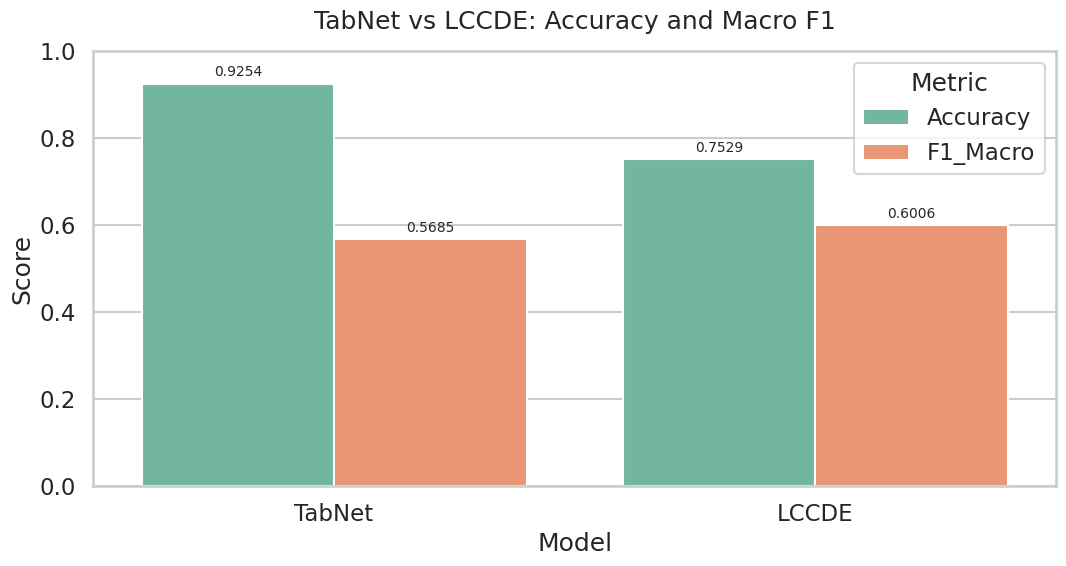

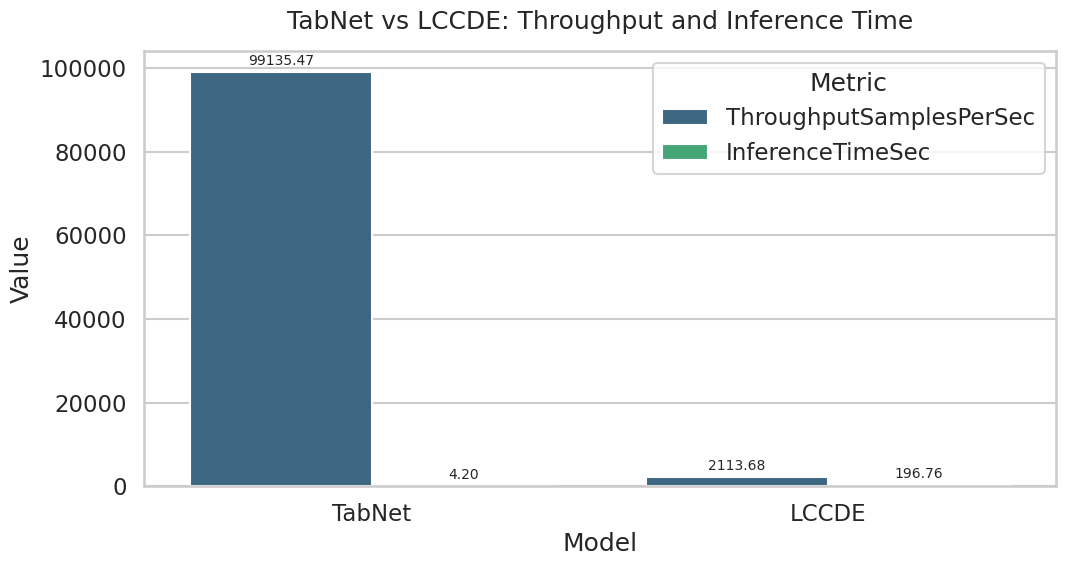

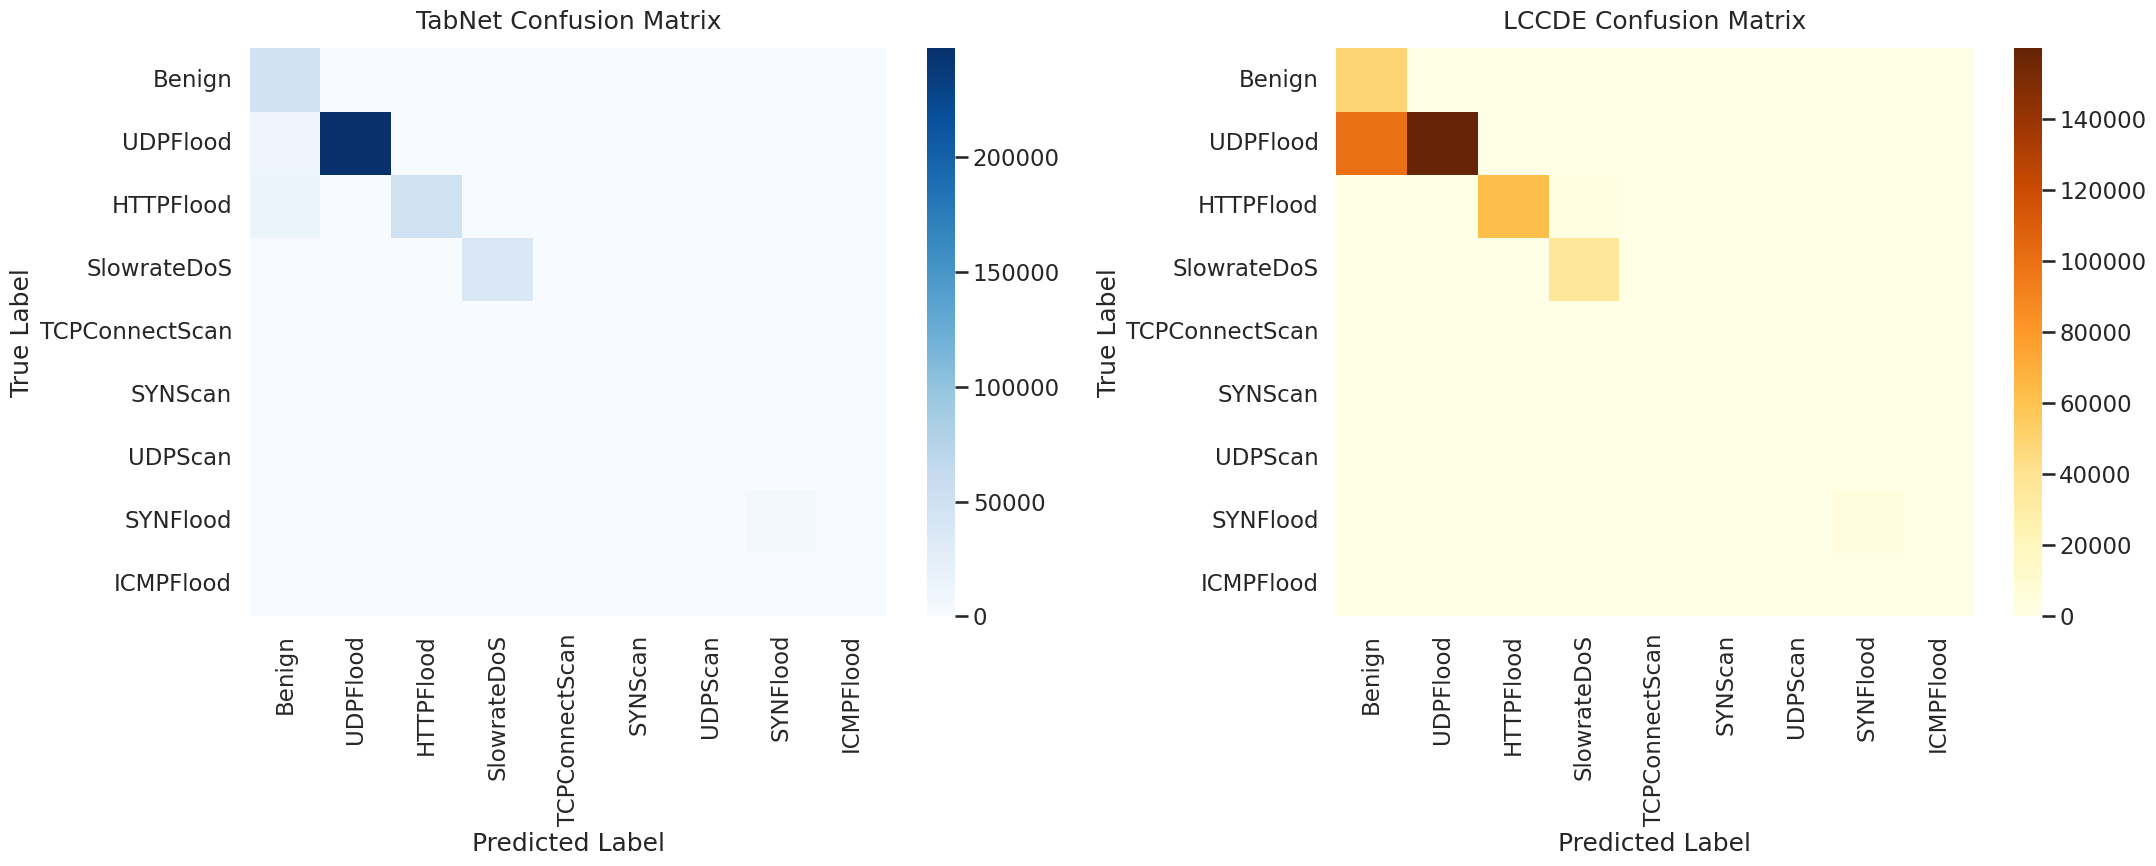


All models, scaler, benchmark CSV, and figures are saved to:
/content/drive/MyDrive/5gnidd_outputs


In [ ]:
sns.set_theme(style='whitegrid', context='talk')

metrics_plot_df = benchmark_df[['Model', 'Accuracy', 'F1_Macro']].melt(
    id_vars='Model',
    value_vars=['Accuracy', 'F1_Macro'],
    var_name='Metric',
    value_name='Score',
)

plt.figure(figsize=(11, 6))
ax = sns.barplot(data=metrics_plot_df, x='Model', y='Score', hue='Metric', palette='Set2')
ax.set_title('TabNet vs LCCDE: Accuracy and Macro F1', pad=16)
ax.set_ylim(0, 1.0)
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3, fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'metrics_comparison_bar.png', dpi=300, bbox_inches='tight')
plt.show()

runtime_plot_df = benchmark_df[['Model', 'ThroughputSamplesPerSec', 'InferenceTimeSec']].melt(
    id_vars='Model',
    value_vars=['ThroughputSamplesPerSec', 'InferenceTimeSec'],
    var_name='Metric',
    value_name='Value',
)

plt.figure(figsize=(11, 6))
ax = sns.barplot(data=runtime_plot_df, x='Model', y='Value', hue='Metric', palette='viridis')
ax.set_title('TabNet vs LCCDE: Throughput and Inference Time', pad=16)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'runtime_comparison_bar.png', dpi=300, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

sns.heatmap(
    tabnet_metrics['confusion_matrix'],
    cmap='Blues',
    annot=False,
    fmt='d',
    xticklabels=ATTACK_TYPE_NAMES,
    yticklabels=ATTACK_TYPE_NAMES,
    ax=axes[0],
)
axes[0].set_title('TabNet Confusion Matrix', pad=14)
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(
    lccde_metrics['confusion_matrix'],
    cmap='YlOrBr',
    annot=False,
    fmt='d',
    xticklabels=ATTACK_TYPE_NAMES,
    yticklabels=ATTACK_TYPE_NAMES,
    ax=axes[1],
)
axes[1].set_title('LCCDE Confusion Matrix', pad=14)
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrices_tabnet_lccde.png', dpi=300, bbox_inches='tight')
plt.show()

joblib.dump({
    'tabnet_metrics': tabnet_metrics,
    'lccde_metrics': lccde_metrics,
    'benchmark': benchmark_df.to_dict(orient='records'),
    'leaders_map': leaders_map,
}, OUTPUT_DIR / 'evaluation_summary.joblib')

print('\nAll models, scaler, benchmark CSV, and figures are saved to:')
print(OUTPUT_DIR)

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()